In [7]:
## Imports

from copy import deepcopy
import numpy as np
from datetime import datetime

start_time = datetime.now()
num_steps = 50

In [8]:
## Ground Truth Simulator

from stonesoup.models.transition.linear import CombinedLinearGaussianTransitionModel,ConstantVelocity
truth_transition_model = CombinedLinearGaussianTransitionModel((ConstantVelocity(0.5), ConstantVelocity(0.5), ConstantVelocity(0.5)))

from stonesoup.simulator.simple import MultiTargetGroundTruthSimulator

from stonesoup.types.state import GaussianState
gt_simulator = MultiTargetGroundTruthSimulator(
    
    transition_model=truth_transition_model,
    initial_state=GaussianState([0, 0, 0, 0, 500, 0], np.diag([100, 1, 100, 1, 100, 1]), 
    timestamp=start_time),
    birth_rate=0,
    death_probability=0,
    number_steps=num_steps,
    preexisting_states=[[-100, 4, -200, 0.5, 500, 0], [0, 5, 300, -0.5, 500, 0]]
)

In [9]:
## Clutter modeling

from stonesoup.models.clutter.clutter import ClutterModel

clutter_model = ClutterModel(
    clutter_rate=2.0,
    distribution=np.random.default_rng().uniform,
    dist_params=((-600.0, 600.0), (-600.0, 600.0), (250.0, 750.0))
)

In [10]:
## Radar modeling and definition

from stonesoup.sensor.radar.radar import RadarElevationBearingRange
from stonesoup.types.array import CovarianceMatrix
from stonesoup.types.array import StateVector
from stonesoup.platform.base import MovingPlatform
from stonesoup.types.state import State

radar1 = RadarElevationBearingRange(
    ndim_state=6,
    position_mapping=(0, 2, 4),
    noise_covar=CovarianceMatrix(np.diag([np.deg2rad(0.005), np.deg2rad(0.005), 0.05])),
    mounting_offset=StateVector([10, 0, 0]),
    clutter_model=clutter_model,
    max_range=3500
)

# Mount the radar onto a moving platform. The platform starts at [-250, 50, 3000]
# with velocity [1, 5, 0] and moves according to a constant velocity model with low noise

sensor1_initial_loc = StateVector([[-250], [1], [50], [5], [3000], [0]])
initial_state = State(sensor1_initial_loc, start_time)

sensor1_transition_model = CombinedLinearGaussianTransitionModel(
    [ConstantVelocity(0.3), ConstantVelocity(0.3), ConstantVelocity(0.3)])

sensor1_platform = MovingPlatform(
    states=initial_state,
    position_mapping=(0, 2, 4),
    velocity_mapping=(1, 3, 5),
    transition_model=sensor1_transition_model,
    sensors=[radar1]
)

radar2_noise_covar = CovarianceMatrix(np.diag([np.deg2rad(0.005), np.deg2rad(0.005), 0.05]))
radar2 = RadarElevationBearingRange(
    ndim_state=6,
    position_mapping=(0, 2, 4),
    noise_covar=radar2_noise_covar,
    clutter_model=clutter_model,
    max_range=3000
)

# Make a platform and mount the radar
from stonesoup.platform.base import FixedPlatform
sensor2_platform = FixedPlatform(
    State([2000, 0, 50, 0, 0, 0]),
    position_mapping=[0, 2, 4],
    sensors=[radar2]
)

In [11]:
## Detection simulator

from itertools import tee
from stonesoup.feeder.multi import MultiDataFeeder
from stonesoup.simulator.platform import PlatformDetectionSimulator

gt_sims = tee(gt_simulator, 2)

radar1_simulator = PlatformDetectionSimulator(
    groundtruth=gt_sims[0],
    platforms=[sensor1_platform]
)
radar1_plotting, radar1_simulator, s1_detector = tee(radar1_simulator, 3)

radar2_simulator = PlatformDetectionSimulator(
    groundtruth=gt_sims[1],
    platforms=[sensor2_platform]
)
radar2_plotting, radar2_simulator, s2_detector = tee(radar2_simulator, 3)

s1s2_detector = MultiDataFeeder([radar1_simulator, radar2_simulator])

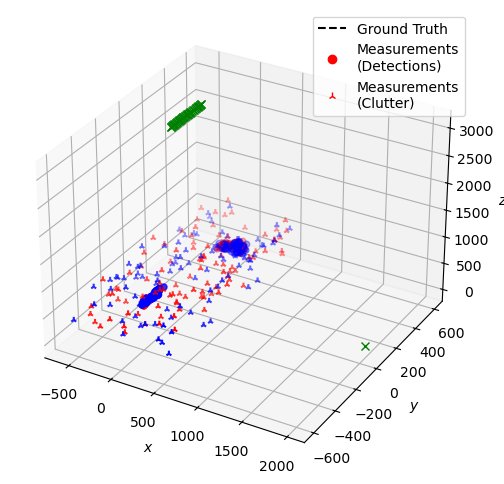

In [12]:
## Plotting

from stonesoup.plotter import Plotter, Dimension

# Lists to hold the detections from each sensor and the path of the airborne radar
s1_detections = set()
s2_detections = set()
radar1_path = []
truths = set()

# Iterate over the time steps, extracting the detections, truths, and airborne sensor path
for (time, s1ds), (_, s2ds) in zip(radar1_plotting, radar2_plotting):
    s1_detections.update(s1ds)
    s2_detections.update(s2ds)
    radar1_path.append(sensor1_platform.position)
    truths.update(gt_simulator.groundtruth_paths)

# Plot the truths and detections
plotter = Plotter(dimension=Dimension.THREE)
plotter.plot_ground_truths(truths, [0, 2, 4])
plotter.plot_measurements(s1_detections, [0, 2, 4], color='blue')
plotter.plot_measurements(s2_detections, [0, 2, 4], color='red')

# Plot the radar positions
plotter.ax.plot(*zip(*radar1_path), marker='x', color='green')
plotter.ax.plot(2000, 50, 0, marker='x', color='green')

In [13]:
## Clutter spatial density definition

clutter_area = np.prod(np.diff(clutter_model.dist_params))
clutter_spatial_density = clutter_model.clutter_rate/clutter_area

In [14]:
## JPDA tracker generation

from stonesoup.hypothesiser.probability import PDAHypothesiser
from stonesoup.updater.kalman import ExtendedKalmanUpdater
from stonesoup.predictor.kalman import ExtendedKalmanPredictor
from stonesoup.dataassociator.probability import JPDA
from stonesoup.deleter.error import CovarianceBasedDeleter
from stonesoup.initiator.simple import MultiMeasurementInitiator
from stonesoup.tracker.simple import MultiTargetMixtureTracker

# Updater
jpda_updater = ExtendedKalmanUpdater(measurement_model=None)

# Data Associator
predictor = ExtendedKalmanPredictor(truth_transition_model)

hypothesiser = PDAHypothesiser(
    predictor=predictor,
    updater=jpda_updater,
    clutter_spatial_density=clutter_spatial_density,
    prob_detect=0.9
)
data_associator = JPDA(hypothesiser=hypothesiser)

# Deleter
covariance_limit_for_delete = 500
deleter = CovarianceBasedDeleter(covar_trace_thresh=covariance_limit_for_delete)

# Initiator
s_prior_state = GaussianState([0, 0, 0, 0, 500, 0], np.diag([0, 50, 0, 50, 0, 50]))

from stonesoup.hypothesiser.distance import DistanceHypothesiser
from stonesoup.measures import Mahalanobis

hypothesiser = DistanceHypothesiser(
    predictor,
    jpda_updater,
    measure=Mahalanobis(),
    missed_distance=3
)

from stonesoup.dataassociator.neighbour import GNNWith2DAssignment

initiator_associator = GNNWith2DAssignment(hypothesiser)
initiator_deleter = CovarianceBasedDeleter(covar_trace_thresh=500)

initiator = MultiMeasurementInitiator(
    prior_state=s_prior_state,
    measurement_model=None,
    deleter=initiator_deleter,
    data_associator=initiator_associator,
    updater=jpda_updater,
    min_points=2
)

jpda_tracker = MultiTargetMixtureTracker(
    initiator=initiator,
    deleter=deleter,
    detector=s1_detector,
    data_associator=data_associator,
    updater=jpda_updater
)
jpda_tracker, s1_tracker = tee(jpda_tracker, 2)

In [15]:
## GM-LLC Tracker for the second sensor

from stonesoup.updater.pointprocess import LCCUpdater
from stonesoup.hypothesiser.distance import DistanceHypothesiser
from stonesoup.measures import Mahalanobis
from stonesoup.hypothesiser.gaussianmixture import GaussianMixtureHypothesiser
from stonesoup.mixturereducer.gaussianmixture import GaussianMixtureReducer
from stonesoup.types.state import TaggedWeightedGaussianState
from stonesoup.tracker.pointprocess import PointProcessMultiTargetTracker

# Updater
kalman_updater = ExtendedKalmanUpdater(measurement_model=None)

updater = LCCUpdater(
    updater=kalman_updater,
    clutter_spatial_density=clutter_spatial_density,
    normalisation=True,
    prob_detection=0.9,
    prob_survival=0.9,
    mean_number_of_false_alarms=clutter_model.clutter_rate,
    variance_of_false_alarms=100
)

# Hypothesiser
kalman_predictor = ExtendedKalmanPredictor(truth_transition_model)

base_hypothesiser = DistanceHypothesiser(
    predictor=kalman_predictor,
    updater=kalman_updater,
    measure=Mahalanobis(),
    missed_distance=15,
    include_all=False
)

hypothesiser = GaussianMixtureHypothesiser(
    base_hypothesiser,
    order_by_detection=True
)

# Reducer
reducer = GaussianMixtureReducer(
    prune_threshold=1E-3,
    pruning=True,
    merge_threshold=200,
    merging=True
)

# Birth component
birth_covar = CovarianceMatrix(np.diag([10000, 10, 10000, 10, 10000, 10]))

birth_component = TaggedWeightedGaussianState(
    state_vector=[0, 0, 0, 0, 500, 0],
    covar=birth_covar**2,
    weight=0.5,
    tag=TaggedWeightedGaussianState.BIRTH,
    timestamp=start_time
)

# Tracker
gmlcc_tracker = PointProcessMultiTargetTracker(
    detector=s2_detector,
    hypothesiser=deepcopy(hypothesiser),
    updater=deepcopy(updater),
    reducer=deepcopy(reducer),
    birth_component=deepcopy(birth_component),
    extraction_threshold=0.90,
)
gmlcc_tracker, s2_tracker = tee(gmlcc_tracker, 2)

In [16]:
## GM-PHD Measurement Fusion

from stonesoup.updater.pointprocess import PHDUpdater

updater = PHDUpdater(
    kalman_updater,
    clutter_spatial_density=clutter_spatial_density,
    prob_detection=0.9,
    prob_survival=0.9
)

meas_fusion_tracker = PointProcessMultiTargetTracker(
    detector=s1s2_detector,
    hypothesiser=deepcopy(hypothesiser),
    updater=deepcopy(updater),
    reducer=deepcopy(reducer),
    birth_component=deepcopy(birth_component),
    extraction_threshold=0.90,
)

In [17]:
## GM-PHD Tracker for Track fusion

from stonesoup.updater.chernoff import ChernoffUpdater
from stonesoup.measures import Euclidean

# Updater
ch_updater = ChernoffUpdater(measurement_model=None)

updater = PHDUpdater(
    ch_updater,
    clutter_spatial_density=1E-15,
    prob_detection=0.9,
    prob_survival=0.9
)


# Hypothesiser
# The states being used as measurements are in Cartesian space. We will use Euclidean distance in
# the :class:`~.DistanceHypothesiser`, meaning that we need a bigger missed distance than the
# previous hypothesiser which used the Mahalanobis distance.
kalman_predictor = ExtendedKalmanPredictor(truth_transition_model)

base_hypothesiser = DistanceHypothesiser(
    kalman_predictor,
    ch_updater,
    Euclidean(),
    missed_distance=300,
    include_all=False
)
hypothesiser = GaussianMixtureHypothesiser(base_hypothesiser, order_by_detection=True)

# Reducer
# The states tend to have low weights when they are first initialized using this method, so we will
# keep the pruning threshold low.
ch_reducer = GaussianMixtureReducer(
    prune_threshold=1E-10,
    pruning=True,
    merge_threshold=200,
    merging=True
)

# Birth component
birth_covar = CovarianceMatrix(np.diag([100000, 100, 100000, 100, 100000, 100]))
ch_birth_component = TaggedWeightedGaussianState(
    state_vector=[0, 0, 0, 0, 500, 0],
    covar=birth_covar**2,
    weight=0.5,
    tag=TaggedWeightedGaussianState.BIRTH,
    timestamp=start_time
)

# Make tracker
from stonesoup.feeder.track import Tracks2GaussianDetectionFeeder

track_fusion_tracker = PointProcessMultiTargetTracker(
    detector=Tracks2GaussianDetectionFeeder(MultiDataFeeder([s1_tracker, s2_tracker])),
    hypothesiser=hypothesiser,
    updater=updater,
    reducer=deepcopy(ch_reducer),
    birth_component=deepcopy(ch_birth_component),
    extraction_threshold=0.90,
)

In [18]:
## Metric manager

from stonesoup.metricgenerator.basicmetrics import BasicMetrics
from stonesoup.metricgenerator.ospametric import OSPAMetric
from stonesoup.metricgenerator.tracktotruthmetrics import SIAPMetrics
from stonesoup.metricgenerator.uncertaintymetric import SumofCovarianceNormsMetric

metric_generators = []

track_labels = ['jpda', 'gmlcc', 'meas_fusion', 'track_fusion']
labels = ['Airborne Radar (JPDAF)', 'Ground Radar (GM-LCC)', 'Measurement Fusion (GM-PHD)',
          'Covariance Intersection (GM-PHD)']

for track_label, label in zip(track_labels, labels):
    # for _ in ['jpda', 'gmlcc', 'meas_fusion', 'track_fusion']:
    metric_generators.extend([BasicMetrics(generator_name=f'basic {label}',
                                           tracks_key=f'{track_label}_tracks',
                                           truths_key='truths'
                                           ),
                              OSPAMetric(c=10, p=1, measure=Euclidean([0, 2, 4]),
                                         generator_name=f'OSPA {label}',
                                         tracks_key=f'{track_label}_tracks',
                                         truths_key='truths'
                                         ),
                              SIAPMetrics(position_measure=Euclidean(), velocity_measure=Euclidean(),
                                          generator_name=f'SIAP {label}',
                                          tracks_key=f'{track_label}_tracks',
                                          truths_key='truths'
                                          ),
                              SumofCovarianceNormsMetric(generator_name=f'Uncertainty {label}',
                                                         tracks_key=f'{track_label}_tracks'
                                                         )

                              ])

from stonesoup.dataassociator.tracktotrack import TrackToTruth
associator = TrackToTruth(association_threshold=30)
from stonesoup.metricgenerator.manager import MultiManager
metric_manager = MultiManager(metric_generators, associator=associator)


## 8: Run Simulation



In [19]:
## Simulation

jpda_tracks, gmlcc_tracks = set(), set()
meas_fusion_tracks, track_fusion_tracks = set(), set()

meas_fusion_tracker_iter = iter(meas_fusion_tracker)
track_fusion_tracker_iter = iter(track_fusion_tracker)

for t in range(num_steps):

    # Run JPDA tracker from sensor 1
    _, sensor1_tracks = next(jpda_tracker)
    jpda_tracks.update(sensor1_tracks)

    # Run GM-LCC tracker from sensor 2
    _, sensor2_tracks = next(gmlcc_tracker)
    gmlcc_tracks.update(sensor2_tracks)

    # Run the GM-PHD for measurement fusion. This one gets called twice, once for each set of
    # detections. This ensures there is only one detection per target.
    # Run the GM-PHD for track fusion. Similar to the measurement fusion, this tracker gets run
    # twice, once for each set of tracks.
    for _ in (0, 1):
        _, tracks = next(meas_fusion_tracker_iter)
        meas_fusion_tracks.update(tracks)
        _, tracks = next(track_fusion_tracker_iter)
        track_fusion_tracks.update(tracks)

detections = s1_detections | s2_detections
metric_manager.add_data({'truths': truths, 'detections': detections}, overwrite=False)

# Remove tracks that have just one state in them as they were probably from clutter
jpda_tracks = {track for track in jpda_tracks if len(track) > 1}
gmlcc_tracks = {track for track in gmlcc_tracks if len(track) > 1}
meas_fusion_tracks = {track for track in meas_fusion_tracks if len(track) > 1}
track_fusion_tracks = {track for track in track_fusion_tracks if len(track) > 1}

# Add track data to the metric manager
metric_manager.add_data({'jpda_tracks': jpda_tracks,
                         'gmlcc_tracks': gmlcc_tracks,
                         'meas_fusion_tracks': meas_fusion_tracks,
                         'track_fusion_tracks': track_fusion_tracks
                         }, overwrite=False)

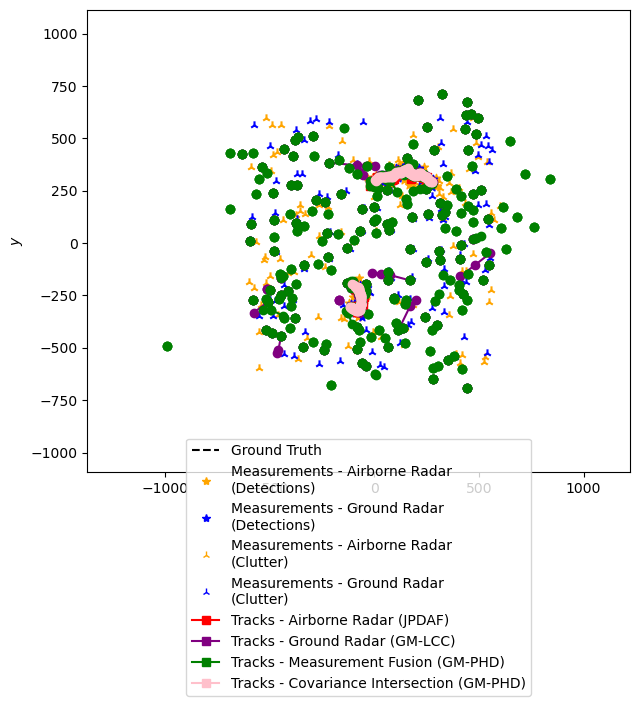

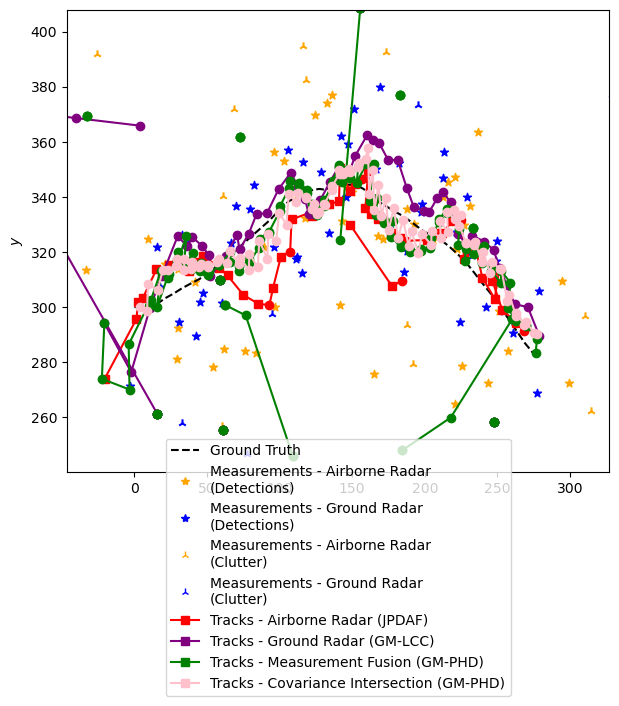

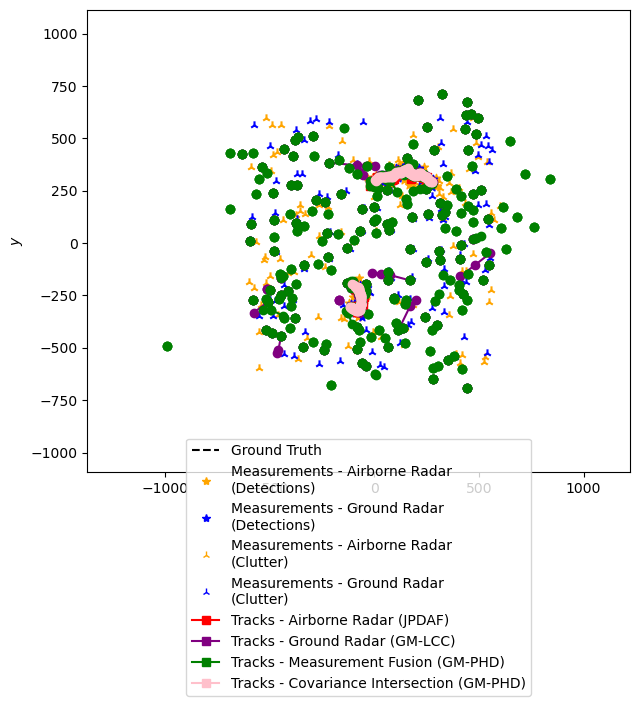

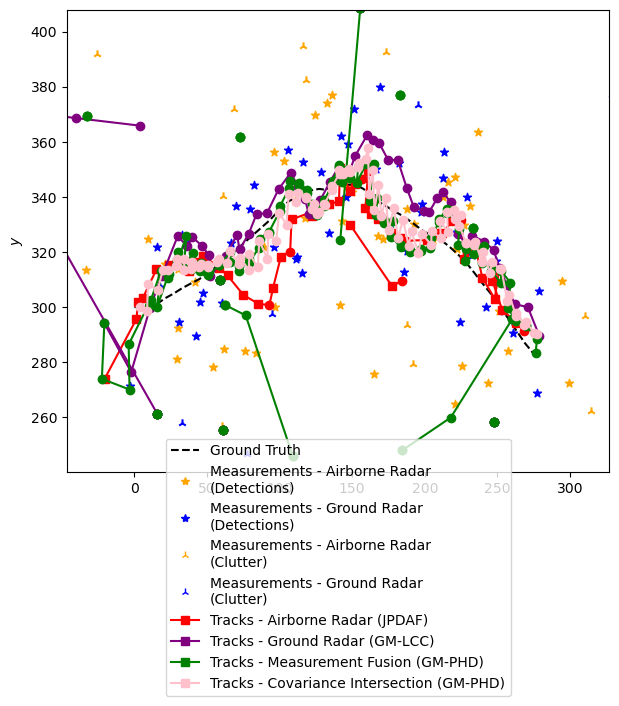

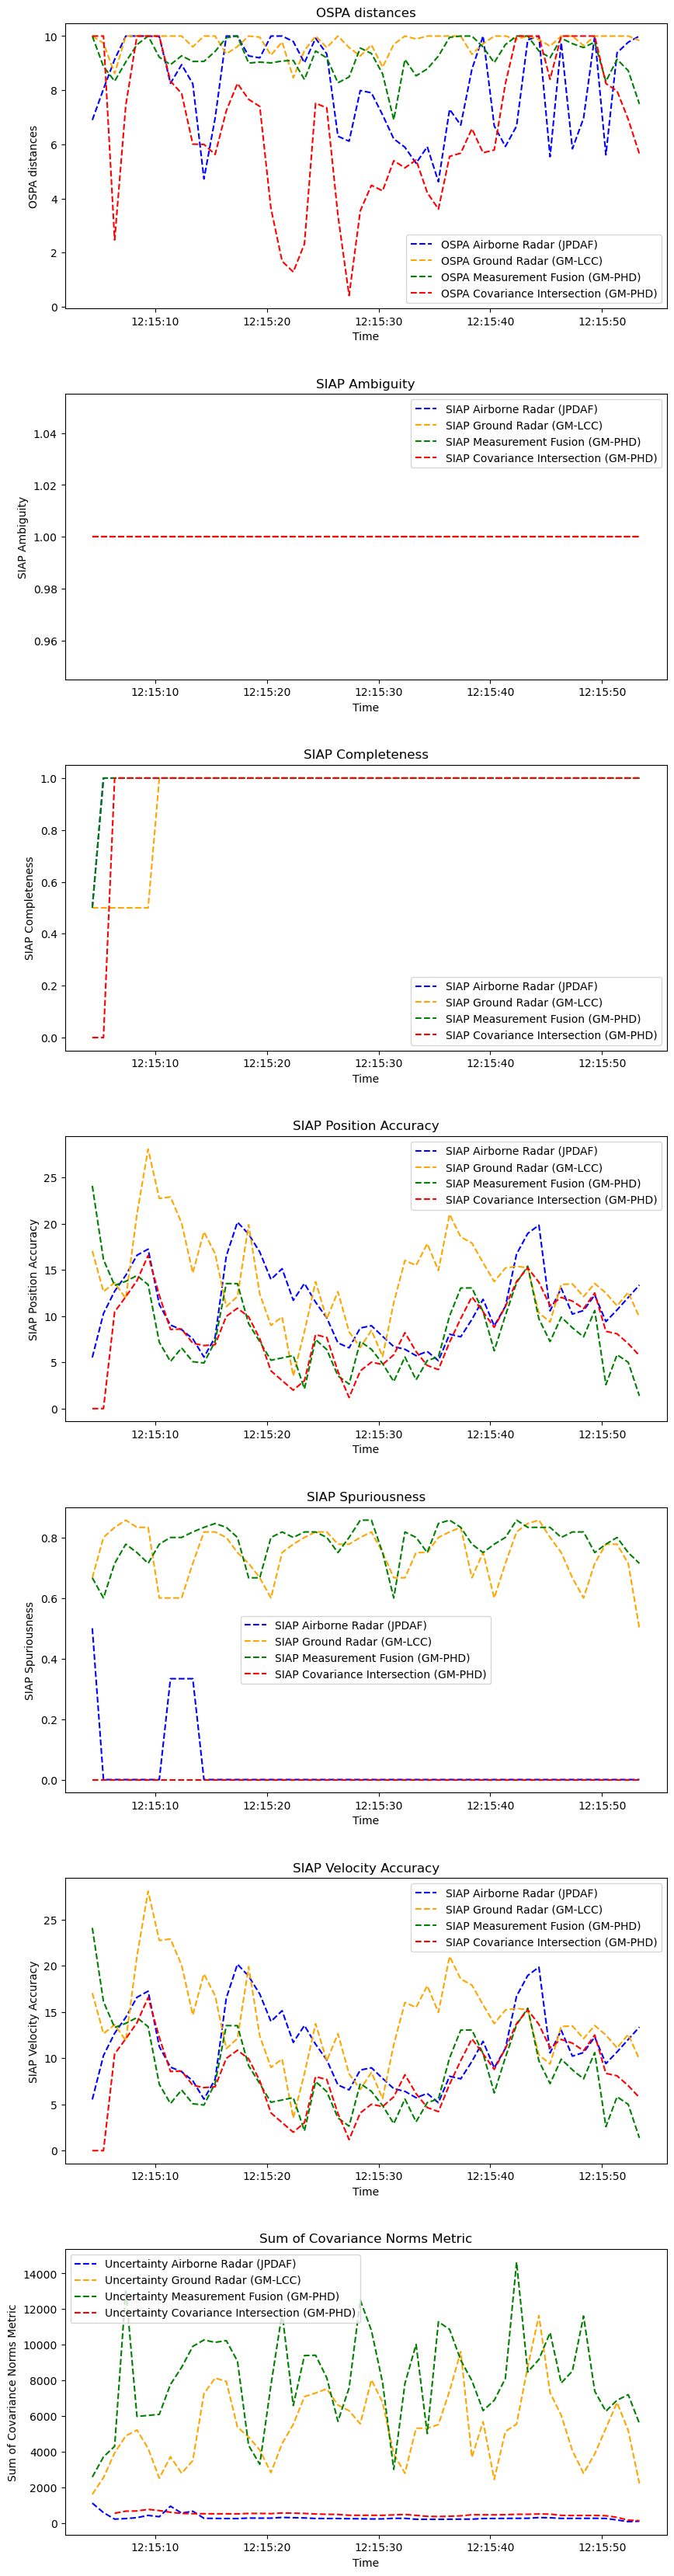

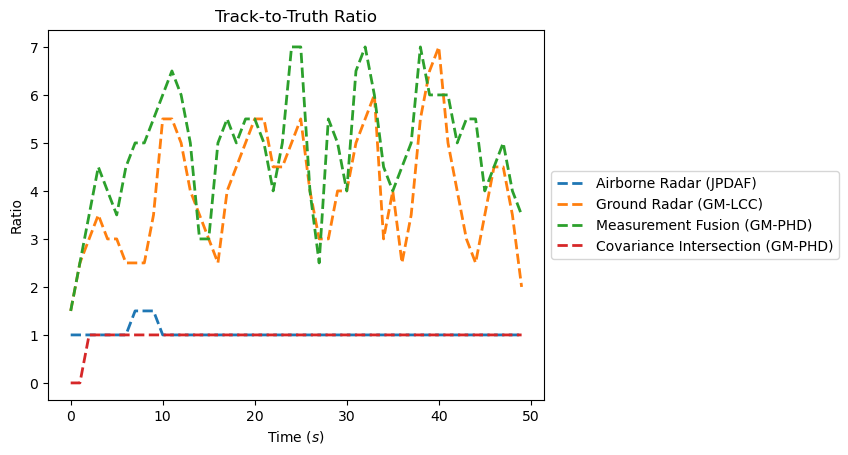

In [24]:
## Results plotting

plotter1, plotter2 = Plotter(), Plotter()
for plotter in [plotter1, plotter2]:
    plotter.plot_ground_truths(truths, [0, 2],
                               color='black')
    plotter.plot_measurements(s1_detections, [0, 2], color='orange', marker='*',
                              label='Measurements - Airborne Radar')
    plotter.plot_measurements(s2_detections, [0, 2], color='blue', marker='*',
                              label='Measurements - Ground Radar')
    plotter.plot_tracks(jpda_tracks, [0, 2], color='red',
                        label='Tracks - Airborne Radar (JPDAF)')
    plotter.plot_tracks(gmlcc_tracks, [0, 2], color='purple',
                        label='Tracks - Ground Radar (GM-LCC)')
    plotter.plot_tracks(meas_fusion_tracks, [0, 2], color='green',
                        label='Tracks - Measurement Fusion (GM-PHD)')
    plotter.plot_tracks(track_fusion_tracks, [0, 2], color='pink',
                        label='Tracks - Covariance Intersection (GM-PHD)')

    # Format the legend a bit. Set the position outside of the plot, and
    # swap the order of the clutter and ground radar measurements
    pos = plotter.ax.get_position()
    plotter.ax.set_position([pos.x0, pos.y0, pos.width * 0.7, pos.height])
    k = list(plotter.legend_dict.keys())
    k[2], k[3] = k[3], k[2]
    v = list(plotter.legend_dict.values())
    v[2], v[3] = v[3], v[2]
    plotter.ax.legend(handles=v, labels=k, loc='lower center', bbox_to_anchor=(0.5, -0.5))

display(plotter1.fig)

track = sorted(track_fusion_tracks, key=len)[-1]  # Longest track
x_min = min([state.state_vector[0] for state in track])
x_max = max([state.state_vector[0] for state in track])
y_min = min([state.state_vector[2] for state in track])
y_max = max([state.state_vector[2] for state in track])

plotter2.ax.set_xlim(x_min-50, x_max+50)
plotter2.ax.set_ylim(y_min-50, y_max+50)
plotter2.ax.set_aspect('auto') 
display(plotter2.fig)

metrics = metric_manager.generate_metrics()

from stonesoup.plotter import MetricPlotter

fig = MetricPlotter()
fig.plot_metrics(metrics, color=['blue', 'orange', 'green', 'red'], linestyle='--')

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
times = metric_manager.list_timestamps(metric_manager.generators[2])

# Iterate through the trackers. For each one, go through the list of all timesteps
# and calculate the ratio at that time
for track_label, label in zip(track_labels, labels):
    ratios = []
    for time in times:
        num_tracks = SIAPMetrics.num_tracks_at_time(metric_manager.states_sets[f'{track_label}_tracks'], timestamp=time)
        num_truths = SIAPMetrics.num_truths_at_time(metric_manager.states_sets['truths'], timestamp=time)
        ratios.append(num_tracks / num_truths)
    plt.plot(ratios, linewidth=2, label=label, linestyle='--')

ax.set_title('Track-to-Truth Ratio')
ax.set_ylabel('Ratio')
ax.set_xlabel('Time $(s)$')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))